<a href="https://colab.research.google.com/github/TitiOjutiku/A02-QNS25001-KMD24003/blob/add-model-evaluation/California_housing%20with%20training%20plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Features + target as a single DataFrame
df = housing.frame

# Quick check
print(df.head())
print(df.shape)

# you can save the boxplot...

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


In [2]:
from sklearn.model_selection import train_test_split

# Split data into features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [3]:
from sklearn.neural_network import MLPRegressor

# Create the MLP regression model
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Train the model
mlp_model.fit(X_train, y_train)

print("MLP Regression model trained successfully.")

MLP Regression model trained successfully.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training data
y_train_pred = mlp_model.predict(X_train)

print("Training predictions generated successfully.")

Training predictions generated successfully.


### Visualizing Training Predictions

These plots help to understand how well the model is performing on the training data:

1.  **Actual vs. Predicted Plot**: This scatter plot compares the actual `MedHouseVal` (y_train) with the predicted `MedHouseVal` (y_train_pred). A perfect model would show all points falling on a 45-degree line.

2.  **Residual Plot**: This plot shows the difference between the actual and predicted values (residuals) against the predicted values. Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying patterns well and there are no systematic errors.

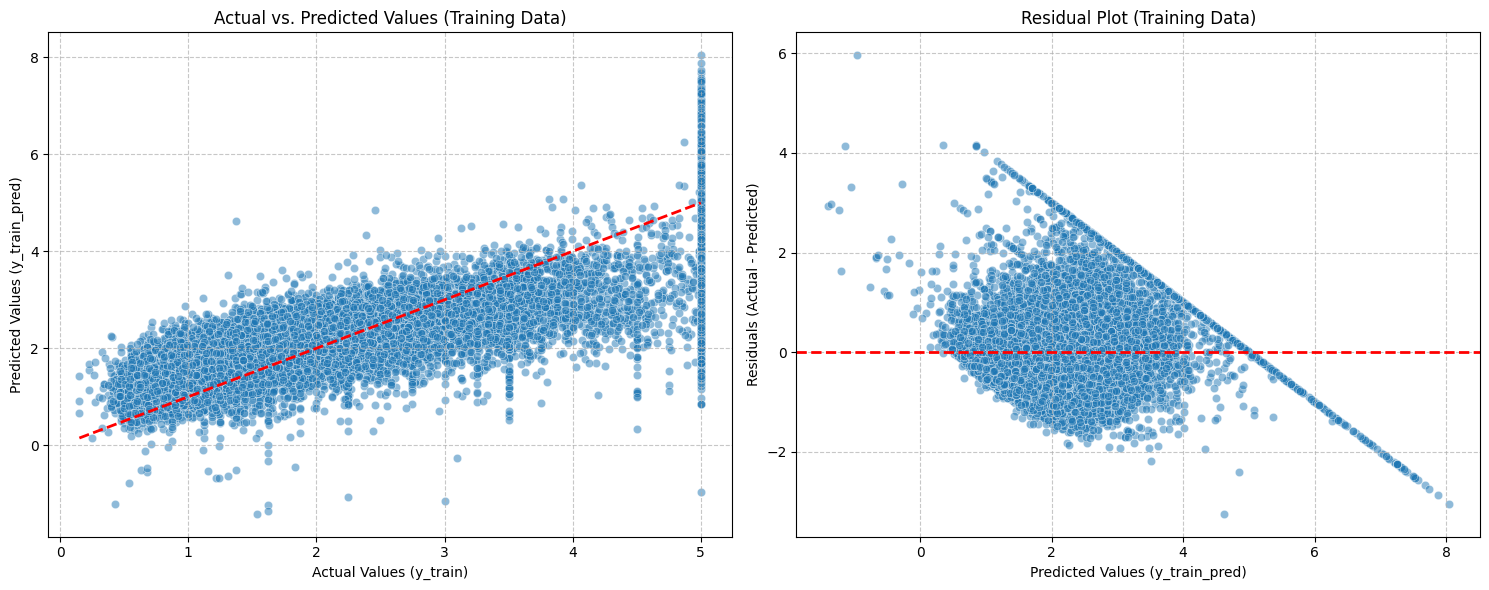

In [5]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs. Predicted values
sns.scatterplot(x=y_train, y=y_train_pred, ax=axes[0], alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # Ideal line
axes[0].set_xlabel('Actual Values (y_train)')
axes[0].set_ylabel('Predicted Values (y_train_pred)')
axes[0].set_title('Actual vs. Predicted Values (Training Data)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Residuals vs. Predicted values
residuals = y_train - y_train_pred
sns.scatterplot(x=y_train_pred, y=residuals, ax=axes[1], alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
axes[1].set_xlabel('Predicted Values (y_train_pred)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot (Training Data)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
# Save the figure to a file
plot_filename = 'training_predictions_plots.png'
fig.savefig(plot_filename)

print(f"Plots saved to {plot_filename}")

Plots saved to training_predictions_plots.png


In [7]:
# Model Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Generate predictions on the test data
y_test_pred = mlp_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Display results
print("Model Evaluation - Test Data")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Model Evaluation - Test Data
MSE:  0.6102
RMSE: 0.7812
MAE:  0.5857
R²:   0.5343


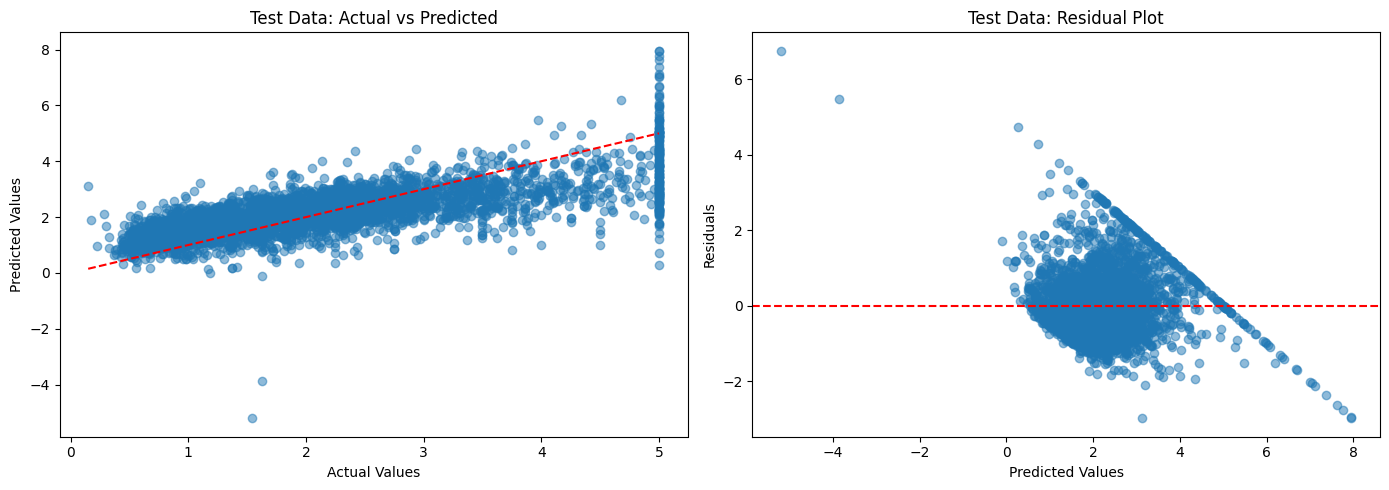

Test evaluation plots saved as test_evaluation_plots.png


In [8]:
# Test Set Evaluation Plots

import matplotlib.pyplot as plt

# Calculate residuals
test_residuals = y_test - y_test_pred

# Create evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Test Data: Actual vs Predicted")

# Residual Plot
axes[1].scatter(y_test_pred, test_residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Test Data: Residual Plot")

plt.tight_layout()

# Save plot
plt.savefig("test_evaluation_plots.png", dpi=300, bbox_inches="tight")

plt.show()

print("Test evaluation plots saved as test_evaluation_plots.png")